In [44]:
import numpy as np
import pandas as pd
import scipy.optimize as sco
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime
import seaborn as sns
import cvxpy as cp

In [2]:
%config InlineBackend.figure_format ='retina'
sns.set(style="whitegrid")

## Mean Variance Optimisation

Introduced by Harry Markowitz in the 1950s, is the foundation of modern portfolio theory. It answers this core question:

❓ How do I allocate my capital across different assets to achieve the best possible trade-off between expected return and risk?

$$ \min_{\mathbf{w}} \quad \mathbf{w}^\top \Sigma \mathbf{w}
\quad \text{subject to:} \quad
\mathbf{w}^\top \mu = \mu_p, \quad \mathbf{w}^\top \mathbf{1} = 1 $$

### Efficient Frontier

The set of optimal portfolios offering the highest return for a given risk level

In [38]:
# Assets
tickers = ['SPY', 'QQQ', 'TLT', 'GLD', 'EEM']
start_date = "2020-01-01"
end_date = datetime.today().strftime('%Y-%m-%d')

# Download data
data = yf.download(tickers, start=start_date, end=end_date)["Close"]
returns = data.pct_change().dropna()

[*********************100%***********************]  5 of 5 completed


In [15]:
data.head()

Ticker,EEM,GLD,QQQ,SPY,TLT
Date,,,,,
2020-01-02,41.054634,143.949997,209.325882,300.291595,119.346962
2020-01-03,40.292366,145.860001,207.408463,298.017700,121.184921
2020-01-06,40.193722,147.389999,208.744843,299.154663,120.496773
2020-01-07,40.166824,147.970001,208.715820,298.313507,119.904488
2020-01-08,40.399982,146.860001,210.284607,299.903381,119.111816


In [39]:
mean_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252

In [17]:
# Portfolio simulation
num_portfolios = 5000
results = np.zeros((3, num_portfolios))
risk_free_rate = 0.02

for i in range(num_portfolios):
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)
    ret = np.dot(weights, mean_returns)
    std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe = (ret - risk_free_rate) / std
    results[:, i] = [ret, std, sharpe]

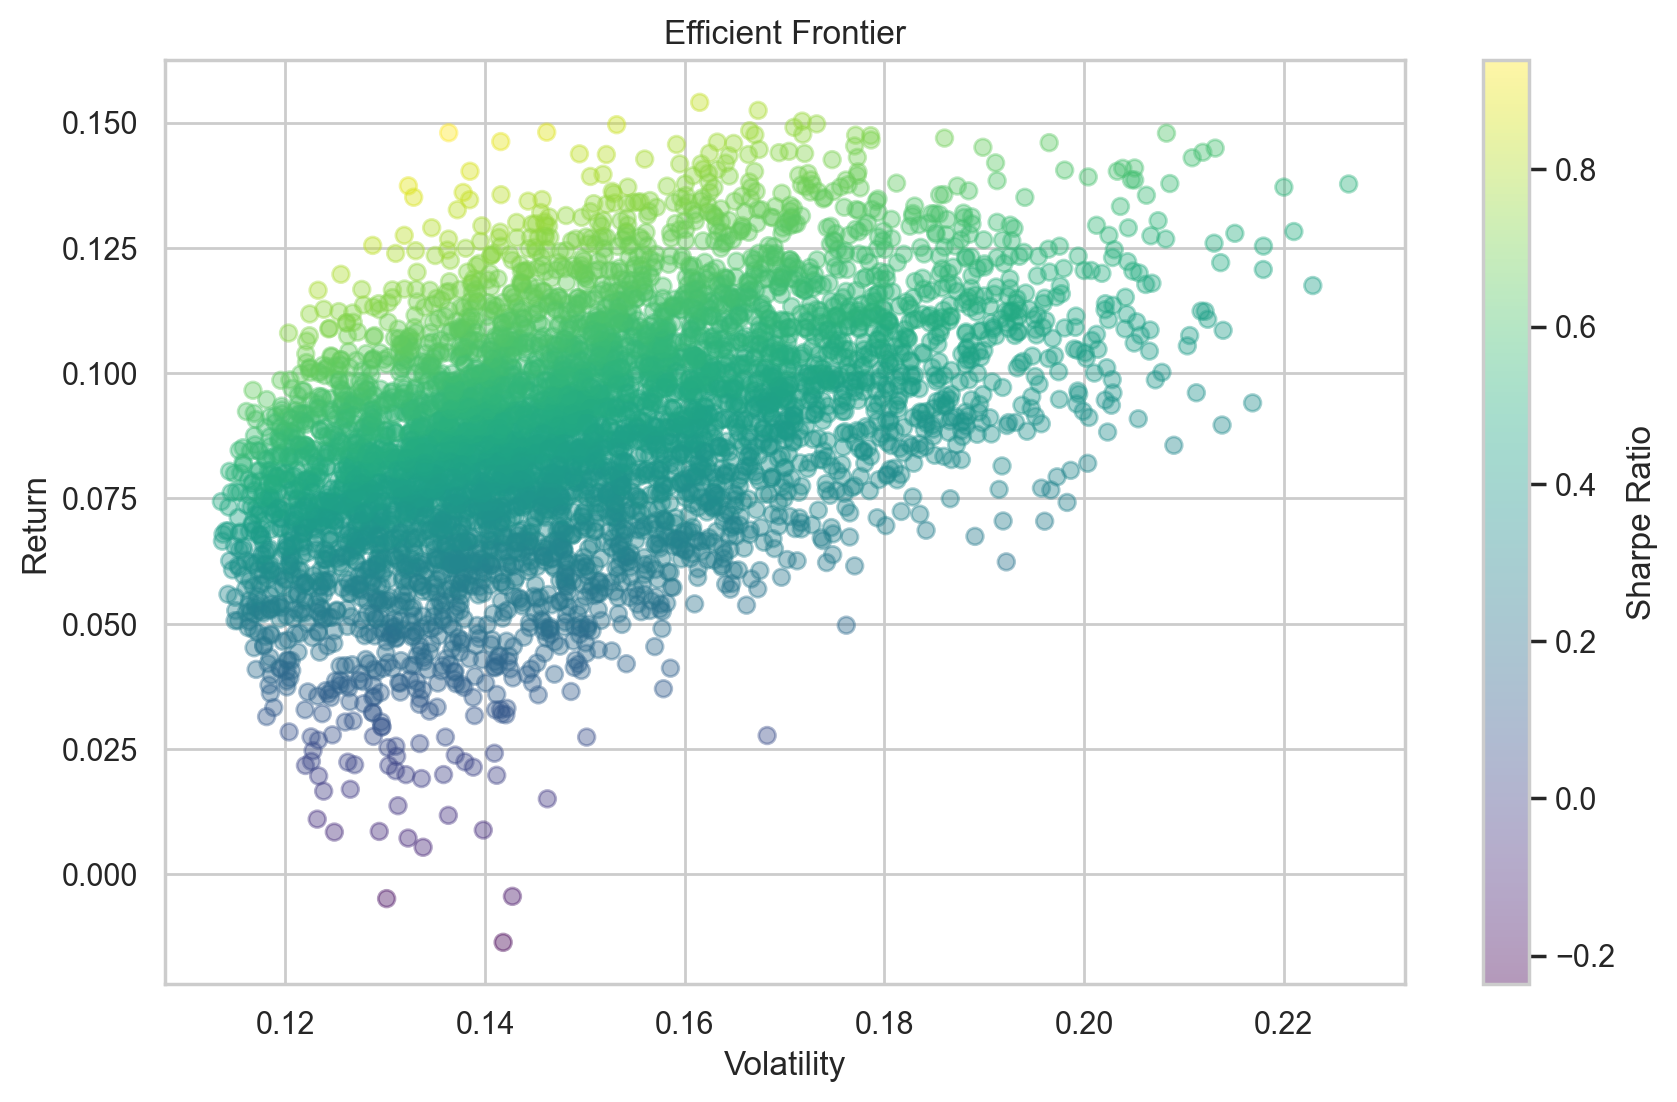

In [18]:
# Plot
plt.figure(figsize=(10,6))
plt.scatter(results[1], results[0], c=results[2], cmap='viridis', alpha=0.4)
plt.xlabel("Volatility")
plt.ylabel("Return")
plt.title("Efficient Frontier")
plt.colorbar(label="Sharpe Ratio")
plt.grid(True)
plt.show()

In [34]:
# Simulated asset returns (example)
np.random.seed(42)
n_assets = 5
returns = np.random.randn(1000, n_assets) * 0.02 
# Compute mean returns and covariance matrix
mean_returns = np.mean(returns, axis=0)
cov_matrix = np.cov(returns.T)

In [40]:
# Portfolio statistics function
def portfolio_stats(weights, mean_returns, cov_matrix):
    port_return = np.dot(weights, mean_returns)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    
    return port_return, port_vol, port_return / port_vol  # Sharpe Ratio

### Running optimisation using scipy

Test both simulations and market data

In [42]:
# Optimization function
def min_variance(weights):
    return portfolio_stats(weights, mean_returns, cov_matrix)[1]  # Minimize Volatility

# Constraints & Bounds
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})  # Sum of weights = 1
bounds = tuple((0, 1) for _ in range(n_assets))  # No short selling
init_guess = [1./5.] * 5

# Optimization
opt_results = sco.minimize(min_variance, init_guess, bounds=bounds, constraints=constraints)
opt_weights = opt_results.x

print("Optimal Weights:", opt_weights)

Optimal Weights: [0.03901448 0.3465099  0.         0.2429417  0.37153392]


### Optimisation using cvxpy library

In [43]:
# Assume mean_returns and cov_matrix are defined as in your original code
n_assets = len(mean_returns)
w = cp.Variable(n_assets)

# Objective: Minimize portfolio variance
portfolio_variance = cp.quad_form(w, cov_matrix)
objective = cp.Minimize(portfolio_variance)

# Constraints: weights sum to 1, no short selling
constraints = [
    cp.sum(w) == 1,
    w >= 0,
    w <= 1
]

# Solve problem
problem = cp.Problem(objective, constraints)
problem.solve()

# Results
opt_weights = w.value
print("Optimal Weights (CVXPY):", opt_weights)

Optimal Weights (CVXPY): [ 3.95938946e-02  3.47404258e-01 -1.78741629e-22  2.41726007e-01
  3.71275841e-01]
